### Hyperparameters

In [1]:
SEED = 42
VAL_FRACTION = 0.08
MAX_LABEL_TOKENS = 64
EPOCHS = 20
TRAIN_BATCH = 4
EVAL_BATCH = 4
LEARNING_RATE = 5e-5
WARMUP_RATIO = 0.05
LOGGING_STEPS = 25
# 1.0 is the HF default and the value used by standard TrOCR recipes; values much
# smaller (e.g. 0.1) clip almost every step and effectively freeze training.
MAX_GRAD_NORM = 1.0
GEN_MAX_LEN = 64
# Greedy during epoch eval keeps training fast; final test eval re-runs with
# beam search (cell that calls `evaluate_model_on_df` on the test set).
GEN_NUM_BEAMS = 1
FINAL_EVAL_NUM_BEAMS = 4

# Regularization / stopping
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.0
EARLY_STOPPING_PATIENCE = 2

# Data augmentation toggle (train split only)
USE_AUGMENTATION = True

# Optional throughput knobs
GRAD_ACCUM_STEPS = 1

# DataLoader workers: parallel image decode + batching (faster on CPU I/O). Use 0 if workers crash.
DATALOADER_NUM_WORKERS = 6

### Dataset

In [2]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from transformers import TrOCRProcessor
from torch.utils.data import random_split, DataLoader
import torch

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

class RxHandBDDataset(Dataset):
    def __init__(self, csv_path, image_dir, processor):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]  # Get the row at index idx

        image_path = os.path.join(self.image_dir, row["Images"])
        image = Image.open(image_path).convert("RGB")

        text = row["Text"]

        # Converting our image pixels to tensor
        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        # Convert our ground truth to token ids
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=64,
            truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # Dataloader automatically batches these so its fine
        return {
            "pixel_values": pixel_values,
            "labels": labels,
        }

In [3]:
dataset = RxHandBDDataset(
    "/workspace/RxHandBD-ML/Train_Label.csv",
    "/workspace/RxHandBD-ML/Train_Set",
    processor
)

val_fraction = VAL_FRACTION

num_total = len(dataset)
num_val = int(num_total * val_fraction)
num_train = num_total - num_val

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [num_train, num_val],
    generator=generator
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))


train: 4106
val: 357


### DataLoader

In [4]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

def data_collator(features):
    pixel_values = torch.stack([f["pixel_values"] for f in features])
    labels = torch.stack([f["labels"] for f in features])

    return {
        "pixel_values": pixel_values,
        "labels": labels,
    }

### Align the Model to the Processor. 
Make sure that start, pad, and eos are the same

In [5]:
def align_model_to_processor(model, processor):
    tokenizer = processor.tokenizer

    model.config.decoder_start_token_id = tokenizer.cls_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.sep_token_id

    model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.sep_token_id

    # Useful for generation later
    model.generation_config.max_length = 64
    model.generation_config.num_beams = 1

    return model

### Define the VisionEncoderDecoder Model

In [6]:
import torch
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda")

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten").to(device)

model = align_model_to_processor(model, processor)



Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Sanity check special token alignment

In [7]:
def check_trocr_alignment(model, processor):
    tokenizer = processor.tokenizer

    expected_decoder_start = tokenizer.cls_token_id
    expected_pad = tokenizer.pad_token_id
    expected_eos = tokenizer.sep_token_id

    checks = {
        "model.config.decoder_start_token_id": (
            model.config.decoder_start_token_id,
            expected_decoder_start,
        ),
        "model.config.pad_token_id": (
            model.config.pad_token_id,
            expected_pad,
        ),
        "model.config.eos_token_id": (
            model.config.eos_token_id,
            expected_eos,
        ),
        "model.generation_config.decoder_start_token_id": (
            model.generation_config.decoder_start_token_id,
            expected_decoder_start,
        ),
        "model.generation_config.pad_token_id": (
            model.generation_config.pad_token_id,
            expected_pad,
        ),
        "model.generation_config.eos_token_id": (
            model.generation_config.eos_token_id,
            expected_eos,
        ),
    }

    for name, (actual, expected) in checks.items():
        assert actual == expected, f"{name}: expected {expected}, got {actual}"

    print("TrOCR alignment check passed.")
    print(f"decoder_start_token_id = {expected_decoder_start}")
    print(f"pad_token_id           = {expected_pad}")
    print(f"eos_token_id           = {expected_eos}")

check_trocr_alignment(model, processor)

TrOCR alignment check passed.
decoder_start_token_id = 0
pad_token_id           = 1
eos_token_id           = 2


### WER, CER, Sequence Accuracy metrics

In [8]:
import numpy as np
import evaluate

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    # Sometimes preds can be a tuple; take the actual generated IDs.
    if isinstance(preds, tuple):
        preds = preds[0]

    pred_texts = processor.batch_decode(
        preds,
        skip_special_tokens=True
    )

    # Replace -100 so tokenizer can decode labels.
    labels = np.where(
        labels == -100,
        processor.tokenizer.pad_token_id,
        labels
    )

    true_texts = processor.batch_decode(
        labels,
        skip_special_tokens=True
    )

    cer = cer_metric.compute(
        predictions=pred_texts,
        references=true_texts
    )

    wer = wer_metric.compute(
        predictions=pred_texts,
        references=true_texts
    )

    seq_acc = np.mean([
        pred == true
        for pred, true in zip(pred_texts, true_texts)
    ])

    return {
        "cer": cer,
        "wer": wer,
        "seq_acc": seq_acc,
    }

In [11]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

OUTPUT_DIR = "outputs/trocr-rxhandbd-trainer"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    logging_steps=LOGGING_STEPS,
    logging_strategy="steps",
    predict_with_generate=True,
    generation_max_length=GEN_MAX_LEN,
    generation_num_beams=GEN_NUM_BEAMS,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    save_total_limit=2,
    remove_unused_columns=False,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=1e-4,
        )
    ],
)

train_out = trainer.train()

trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

val_metrics = trainer.evaluate()
print("Validation:", val_metrics)

# test_dataset = RxHandBDDataset(
#     csv_path="/workspace/rxhandbd/RxHandBD-ML/Test_Label.csv",
#     image_dir="/workspace/rxhandbd/RxHandBD-ML/Test_Set",
#     processor=processor
# )

# test_metrics = trainer.evaluate(
#     eval_dataset=test_dataset,
#     metric_key_prefix="test"
# )

# print("Test:", test_metrics)

Epoch,Training Loss,Validation Loss,Cer,Wer,Seq Acc
1,1.093604,1.037731,0.416799,0.708029,0.375350
2,0.754908,1.014588,0.299363,0.574209,0.431373
3,0.567326,1.097308,0.976115,1.240876,0.431373
4,0.686607,1.010213,0.452229,0.552311,0.445378
5,0.457560,0.980992,0.725717,0.467153,0.543417
6,0.309611,0.979136,0.420382,0.493917,0.554622
7,0.371627,1.039948,0.443073,0.759124,0.543417
8,0.304602,1.035830,0.572054,0.435523,0.549020
9,0.142784,1.036187,0.248010,0.408759,0.593838
10,0.105148,1.073120,0.392118,0.396594,0.607843


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Cer,Wer,Seq Acc
0.000057,1.088517,20,0.104299,0.340633,0.666667


Validation: {'eval_loss': 1.0885173082351685, 'eval_cer': 0.10429936305732485, 'eval_wer': 0.340632603406326, 'eval_seq_acc': 0.6666666666666666}


### Training Graphs

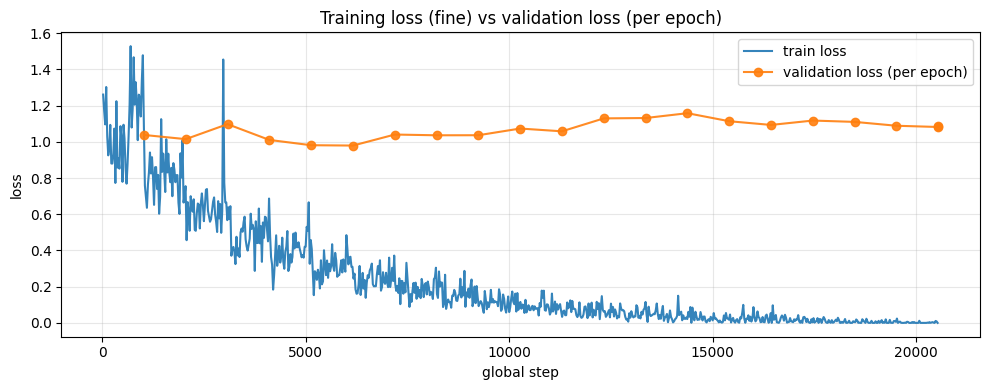

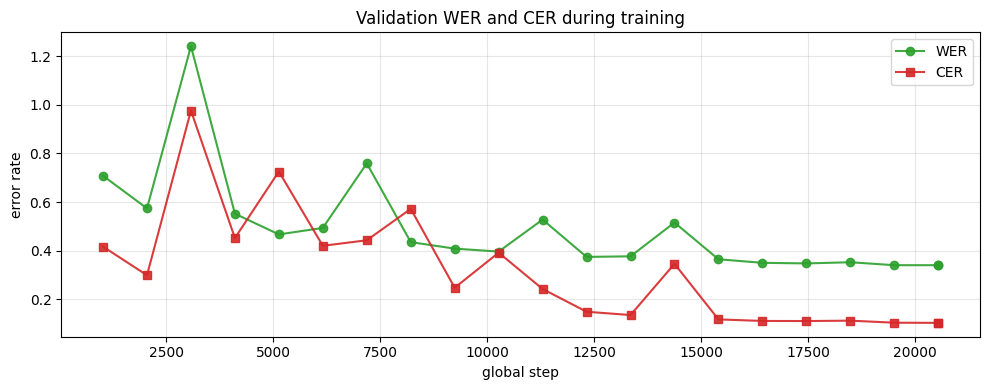

In [12]:
import matplotlib.pyplot as plt


def series(history, key):
    return [(int(r["step"]), float(r[key])) for r in history if key in r]


history = trainer.state.log_history
train_loss = series(history, "loss")
eval_loss = series(history, "eval_loss")
eval_wer = series(history, "eval_wer")
eval_cer = series(history, "eval_cer")

# Figure 1: fine-grained train loss + coarse per-epoch validation loss vs global step
fig1, ax1 = plt.subplots(figsize=(10, 4))
if train_loss:
    xs, ys = zip(*train_loss)
    ax1.plot(xs, ys, label="train loss", color="C0", alpha=0.9)
if eval_loss:
    xs, ys = zip(*eval_loss)
    ax1.plot(
        xs,
        ys,
        label="validation loss (per epoch)",
        color="C1",
        marker="o",
        linestyle="-",
        alpha=0.9,
    )
ax1.set_xlabel("global step")
ax1.set_ylabel("loss")
ax1.set_title("Training loss (fine) vs validation loss (per epoch)")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: eval WER and CER vs global step (per epoch)
fig2, ax2 = plt.subplots(figsize=(10, 4))
if eval_wer:
    xs, ys = zip(*eval_wer)
    ax2.plot(xs, ys, label="WER", color="C2", marker="o", linestyle="-", alpha=0.9)
if eval_cer:
    xs, ys = zip(*eval_cer)
    ax2.plot(xs, ys, label="CER", color="C3", marker="s", linestyle="-", alpha=0.9)
ax2.set_xlabel("global step")
ax2.set_ylabel("error rate")
ax2.set_title("Validation WER and CER during training")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Testing time

Using fine-tuned checkpoint: outputs/trocr-rxhandbd-trainer/checkpoint-20540
Using test CSV: /workspace/RxHandBD-ML/Test_Label.csv
Using test image dir: /workspace/RxHandBD-ML/Test_Set


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

            Model      WER      CER  Line acc (exact)  n (test)
base (pretrained) 1.751011 0.760683          0.080717      1115
fine-tuned (best) 0.709782 0.319044          0.310314      1115

Delta (base - fine)  WER: 1.041229  CER: 0.441638


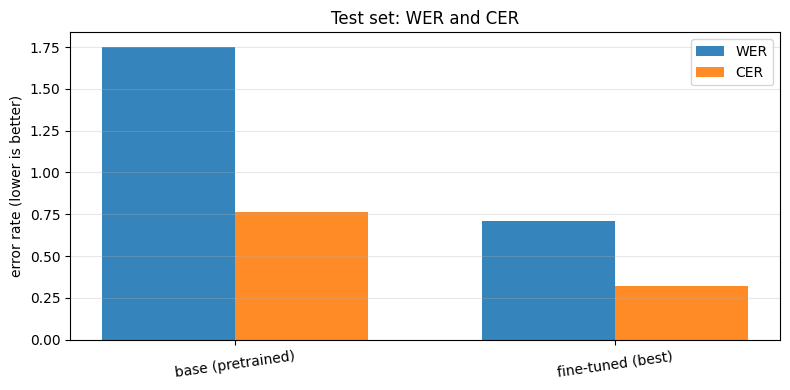

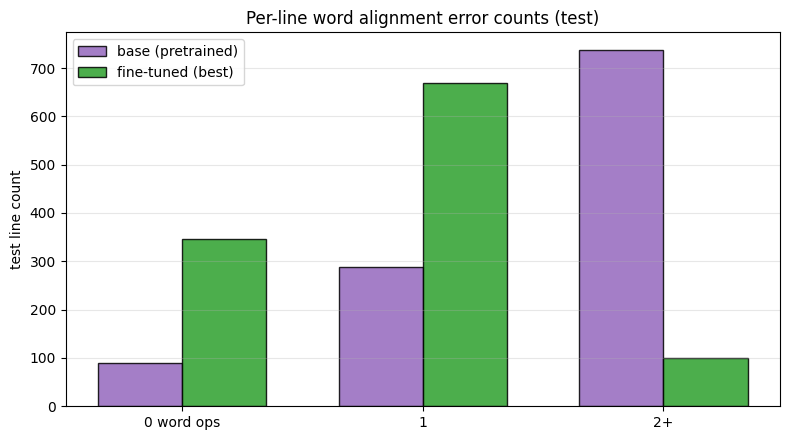

Bucket totals check - base: 1115 / 1115
Bucket totals check - fine: 1115 / 1115


In [13]:
from pathlib import Path
import json
import re
from typing import List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel


def resolve_best_checkpoint(output_dir: str) -> Path:
    """Resolve best fine-tuned checkpoint from trainer metadata, with fallbacks."""
    out = Path(output_dir)
    if not out.exists():
        raise FileNotFoundError(f"Output directory not found: {out.resolve()}")

    # 1) Root trainer_state.json (if present)
    state_path = out / "trainer_state.json"
    if state_path.exists():
        state = json.loads(state_path.read_text())
        best = state.get("best_model_checkpoint")
        if best:
            best_path = Path(best)
            if not best_path.is_absolute():
                best_path = out / best
            if best_path.exists():
                return best_path

    # 2) Newest checkpoint's trainer_state.json (if present)
    ckpt_states = sorted(
        out.glob("checkpoint-*/trainer_state.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    for cp_state in ckpt_states:
        try:
            state = json.loads(cp_state.read_text())
            best = state.get("best_model_checkpoint")
            if best:
                best_path = Path(best)
                if not best_path.is_absolute():
                    best_path = out / best
                if best_path.exists():
                    return best_path
        except Exception:
            pass

    # 3) Fallback to highest checkpoint-* step
    ckpts = [p for p in out.glob("checkpoint-*") if p.is_dir()]
    if ckpts:
        def _step_num(p: Path) -> int:
            m = re.search(r"checkpoint-(\d+)", p.name)
            return int(m.group(1)) if m else -1

        return max(ckpts, key=lambda p: (_step_num(p), p.stat().st_mtime))

    # 4) Last resort: output dir itself (if save_model(OUTPUT_DIR) exists)
    cfg = out / "config.json"
    if cfg.exists():
        return out

    raise FileNotFoundError(
        f"No checkpoint found in {out.resolve()} (no trainer_state.json/checkpoint-*/config.json)."
    )


def resolve_test_paths() -> Tuple[Path, Path]:
    """Find test CSV and image folder using common project layouts."""
    candidates = [
        Path("/workspace/RxHandBD-ML"),
        Path("/workspace/rxhandbd/RxHandBD-ML"),
        Path("real_dataset/RxHandBD-ML"),
        Path("RxHandBD-ML"),
    ]

    for root in candidates:
        csv_path = root / "Test_Label.csv"
        img_dir = root / "Test_Set"
        if csv_path.exists() and img_dir.exists():
            return csv_path, img_dir

    raise FileNotFoundError(
        "Could not locate test data. Expected Test_Label.csv and Test_Set under one of: "
        + ", ".join(str(p) for p in candidates)
    )


def normalize_text_batch(texts: List[str]) -> List[str]:
    return [str(t).strip() for t in texts]


def sequence_accuracy(refs: List[str], preds: List[str]) -> float:
    return float(np.mean([r == p for r, p in zip(refs, preds)])) if refs else 0.0


def word_edit_distance(ref: str, hyp: str) -> int:
    """Levenshtein edit distance on whitespace-tokenized words."""
    a = ref.split()
    b = hyp.split()
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost,
            )
    return dp[m][n]


def per_line_word_error_counts(refs: List[str], preds: List[str]) -> List[int]:
    return [word_edit_distance(r, p) for r, p in zip(refs, preds)]


def evaluate_model_on_test(
    model: VisionEncoderDecoderModel,
    processor: TrOCRProcessor,
    test_df: pd.DataFrame,
    test_img_dir: Path,
    batch_size: int = 4,
    num_beams: Optional[int] = None,
    max_length: Optional[int] = None,
) -> dict:
    model.eval()
    model.to(device)

    num_beams = GEN_NUM_BEAMS if num_beams is None else num_beams
    max_length = GEN_MAX_LEN if max_length is None else max_length

    names = test_df["Images"].astype(str).tolist()
    refs = test_df["Text"].astype(str).tolist()

    preds: List[str] = []

    with torch.no_grad():
        for i in range(0, len(names), batch_size):
            batch_names = names[i : i + batch_size]
            images = [Image.open(test_img_dir / n).convert("RGB") for n in batch_names]

            pixel_values = processor(images=images, return_tensors="pt").pixel_values.to(device)
            out_ids = model.generate(
                pixel_values,
                num_beams=num_beams,
                max_length=max_length,
                early_stopping=True,
            )
            out_text = processor.batch_decode(out_ids, skip_special_tokens=True)
            preds.extend(out_text)

    refs = normalize_text_batch(refs)
    preds = normalize_text_batch(preds)

    return {
        "refs": refs,
        "preds": preds,
        "wer": float(wer_metric.compute(predictions=preds, references=refs)),
        "cer": float(cer_metric.compute(predictions=preds, references=refs)),
        "seq_acc": sequence_accuracy(refs, preds),
        "n_samples": len(refs),
    }


# Resolve artifacts and test data
best_ckpt = resolve_best_checkpoint(OUTPUT_DIR)
print(f"Using fine-tuned checkpoint: {best_ckpt}")

test_csv, test_img_dir = resolve_test_paths()
print(f"Using test CSV: {test_csv}")
print(f"Using test image dir: {test_img_dir}")

test_df = pd.read_csv(test_csv)
test_df.columns = test_df.columns.str.strip()
assert {"Images", "Text"}.issubset(test_df.columns), "Test CSV must contain Images and Text columns"

# Evaluate base model
base_name = "microsoft/trocr-base-handwritten"
proc_base = TrOCRProcessor.from_pretrained(base_name)
mdl_base = VisionEncoderDecoderModel.from_pretrained(base_name).to(device)
mdl_base = align_model_to_processor(mdl_base, proc_base)

res_base = evaluate_model_on_test(
    mdl_base,
    proc_base,
    test_df,
    test_img_dir,
    batch_size=EVAL_BATCH,
    num_beams=GEN_NUM_BEAMS,
    max_length=GEN_MAX_LEN,
)

# Evaluate fine-tuned best checkpoint
proc_ft = TrOCRProcessor.from_pretrained(best_ckpt)
mdl_ft = VisionEncoderDecoderModel.from_pretrained(best_ckpt).to(device)
mdl_ft = align_model_to_processor(mdl_ft, proc_ft)

res_ft = evaluate_model_on_test(
    mdl_ft,
    proc_ft,
    test_df,
    test_img_dir,
    batch_size=EVAL_BATCH,
    num_beams=GEN_NUM_BEAMS,
    max_length=GEN_MAX_LEN,
)

# Summary table
summary = pd.DataFrame(
    {
        "Model": ["base (pretrained)", "fine-tuned (best)"],
        "WER": [res_base["wer"], res_ft["wer"]],
        "CER": [res_base["cer"], res_ft["cer"]],
        "Line acc (exact)": [res_base["seq_acc"], res_ft["seq_acc"]],
        "n (test)": [res_base["n_samples"], res_ft["n_samples"]],
    }
)
print(summary.to_string(index=False))
print()
print(
    "Delta (base - fine)  WER:",
    round(res_base["wer"] - res_ft["wer"], 6),
    " CER:",
    round(res_base["cer"] - res_ft["cer"], 6),
)

# Plot 1: grouped bar for WER/CER by model
x = np.arange(2)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, [res_base["wer"], res_ft["wer"]], w, label="WER", color="C0", alpha=0.9)
ax.bar(x + w / 2, [res_base["cer"], res_ft["cer"]], w, label="CER", color="C1", alpha=0.9)
ax.set_xticks(x, ["base (pretrained)", "fine-tuned (best)"], rotation=8)
ax.set_ylabel("error rate (lower is better)")
ax.set_title("Test set: WER and CER")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: grouped bar for per-line word edit buckets (0 / 1 / 2+)
ops_base = per_line_word_error_counts(res_base["refs"], res_base["preds"])
ops_ft = per_line_word_error_counts(res_ft["refs"], res_ft["preds"])

base_bins = [
    sum(1 for e in ops_base if e == 0),
    sum(1 for e in ops_base if e == 1),
    sum(1 for e in ops_base if e >= 2),
]
ft_bins = [
    sum(1 for e in ops_ft if e == 0),
    sum(1 for e in ops_ft if e == 1),
    sum(1 for e in ops_ft if e >= 2),
]

labels = ["0 word ops", "1", "2+"]
x2 = np.arange(len(labels))
w2 = 0.35

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
ax2.bar(x2 - w2 / 2, base_bins, w2, label="base (pretrained)", color="C4", edgecolor="black", alpha=0.85)
ax2.bar(x2 + w2 / 2, ft_bins, w2, label="fine-tuned (best)", color="C2", edgecolor="black", alpha=0.85)
ax2.set_xticks(x2, labels)
ax2.set_ylabel("test line count")
ax2.set_title("Per-line word alignment error counts (test)")
ax2.legend()
ax2.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bucket totals check - base: {sum(base_bins)} / {res_base['n_samples']}")
print(f"Bucket totals check - fine: {sum(ft_bins)} / {res_ft['n_samples']}")